# 1 &middot; Making feather files from `.par` and `.tim`

**Single-pulsar noise analysis with [Discovery](https://github.com/nanograv/discovery) &mdash; student workshop**

Pulsar timing starts from two files per pulsar:

| file | contents |
|------|----------|
| `*.par` | the **timing model** &mdash; spin, astrometry, binary, DM parameters |
| `*.tim` | the **TOAs** &mdash; the measured pulse times of arrival |

To do noise modelling we first build a pulsar *object*: it reads the `.par`/`.tim`
with **TEMPO2**, fits the timing model, and stores the residuals, the timing-model
**design matrix**, the observing frequencies, backend flags, and so on.

A **feather file** is a compact way to store this Pulsar object. We build it *once*, then every later
notebook loads it back in a fraction of a second with
`discovery.Pulsar.read_feather(...)`.

This workshop bundles the **MeerKAT Pulsar Timing Array (MPTA) DR2** dataset under
`./data/mpta-dr2/` &mdash; 83 millisecond pulsars, each with a `.par`, a `.tim`, and a
pre-built `.feather`. In this notebook you will:

1. look at the raw `.par`/`.tim` data,
2. build one feather by hand to see what is going on,
3. build feathers in batch with the script `make_feather.py`,
4. read a feather back and plot the timing residuals.

In [13]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

# Everything is relative to this notebook, so the whole folder is portable.
DATADIR = "./data/mpta-dr2/"

pars = sorted(glob.glob(os.path.join(DATADIR, "*.par")))
tims = sorted(glob.glob(os.path.join(DATADIR, "*.tim")))
print(f"{len(pars)} par files and {len(tims)} tim files in {DATADIR}")
print("first few pulsars:")
for p in pars[:6]:
    print("  ", os.path.basename(p)[:-4])

83 par files and 83 tim files in ./data/mpta-dr2/
first few pulsars:
   J0030+0451
   J0101-6422
   J0125-2327
   J0437-4715
   J0610-2100
   J0613-0200


### What is inside a `.par` file?

The `.par` is just text: one timing parameter per line (name, value, fit-flag, uncertainty).
Let's peek at the top of one.

In [14]:
psrname = "J0613-0200"   # a well-studied millisecond pulsar
parfile = os.path.join(DATADIR, psrname + ".par")
with open(parfile) as f:
    for line in list(f)[:18]:
        print(line.rstrip())

PSRJ           J0613-0200
ELONG          93.7990080432809485919132264 1  0.00000003278926816768
ELAT           -25.4071384950585643022757942 1  0.00000007273784833321
F0             326.60056196729473521     1  0.00000000001015482290
F1             -1.0231148672128597664e-15 1  3.1151135683140418243e-20
PEPOCH         55636                        8.4405400243152510517e-4941
POSEPOCH       55636
DMEPOCH        58991
DM             38.773426418818040348     1  0.00105243305684829471
DM1            0.00019937467871886054979 1  0.00003162049281474828
DM2            -0.00011758148297992905272 1  0.00002468146857062361
PMELONG        2.0905153070961206686     1  0.01036109914067445466
PMELAT         -10.280800250228797234    1  0.02455552566568014461
PX             0.84963850559199916436       0.06241792304443075784
BINARY         ELL1H
PB             1.1985125750982536686     1  0.00000000001466666666
A1             1.0914401205245539757     1  0.00000057188438838097
PBDOT          3.701625

### Build **one** feather by hand

Under the hood, a feather is made from an `enterprise.pulsar.Pulsar` object (it can be built in other ways, not just enterprise). 
We pass the `.par`, the `.tim`, and a solar-system **ephemeris** (`DE440`). 

> We write into a fresh `my_feathers/` folder so we don't overwrite the feathers
> that already ship with the workshop data.

In [15]:
from enterprise.pulsar import Pulsar

outdir = "./my_feathers"
os.makedirs(outdir, exist_ok=True)

timfile = os.path.join(DATADIR, psrname + ".tim")
psr_ent = Pulsar(parfile, timfile, ephem="DE440")
feather_path = os.path.join(outdir, psrname + ".feather")
psr_ent.to_feather(feather_path)
print("wrote", feather_path)

[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
wrote ./my_feathers/J0613-0200.feather


### Build feathers in **batch** with `make_feather.py`

Doing one pulsar at a time in the notebook is fine for learning, but for a whole
dataset you want a script. `make_feather.py` (next to this notebook) loops over every
matching `.par`/`.tim` pair in a directory and builds each feather in its own
subprocess &mdash; so one bad pulsar can't kill the batch.

```text
python make_feather.py [indir] [outdir] [--ephem DE440]
```

With no arguments it defaults to `indir = ./data/mpta-dr2`. Here we point it at a
**small subset** so the demo is quick (building all 83 with TEMPO2 takes a while &mdash;
that's why we ship the feathers pre-built).

In [18]:
import subprocess, sys, shutil

# Make a tiny par/tim subset to convert as a demonstration
subset_in = "./my_subset_partim/"

result = subprocess.run(
    [sys.executable, "make_feather.py", subset_in, "./my_feathers"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

Found 4 pulsar(s) in ./my_subset_partim/; writing feathers to ./my_feathers

Converting J0613-0200 ...
  -> ./my_feathers/J0613-0200.feather
Converting J1017-7156 ...
  -> ./my_feathers/J1017-7156.feather
Converting J1744-1134 ...
  -> ./my_feathers/J1744-1134.feather
Converting J1909-3744 ...
  -> ./my_feathers/J1909-3744.feather

Done: 4/4 feathers written to ./my_feathers



### Read a feather back and look at the data

This is the call every later notebook uses. Notice how fast it is compared with
building from `.par`/`.tim`. Once loaded we can inspect the residuals, observing
frequencies, and the time span of the dataset. Here we load **J1909-3744** &mdash; one of the
best-timed pulsars in the array &mdash; as the example for the residual plot.

In [23]:
import discovery as ds

# Read back a feather. J1909-3744 is one of the best-timed millisecond pulsars in
# the array, so we use it here as a clean example for the residual plot.
psr = ds.Pulsar.read_feather(os.path.join("./my_feathers", "J1017-7156.feather"))
mjd = psr.toas / 86400.0
print("name        :", psr.name)
print("N TOAs      :", len(psr.toas))
print("MJD range   : %.1f -> %.1f  (%.1f yr)" % (mjd.min(), mjd.max(),
                                                 (mjd.max() - mjd.min()) / 365.25))
print("freq range  : %.0f -> %.0f MHz" % (psr.freqs.min(), psr.freqs.max()))

name        : J1017-7156
N TOAs      : 3321
MJD range   : 58557.2 -> 60156.5  (4.4 yr)
freq range  : 908 -> 1659 MHz


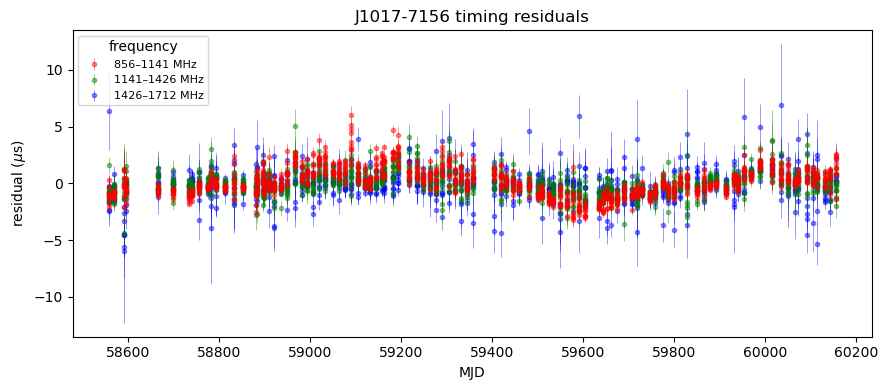

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
res_us = psr.residuals * 1e6      # residuals in microseconds
err_us = psr.toaerrs * 1e6        # per-TOA uncertainties in microseconds

# Use errorbar so the measurement uncertainties are visible. Split the TOAs into a
# few observing-frequency bands so colour still flags any chromatic behaviour.
bands  = [(856, 1141), (1141, 1426), (1426, 1712)]   # MeerKAT L-band, 3 sub-bands
colors = ["red", "green", "blue"]                # low frequency = red, high = blue
for i, ((flo, fhi), col) in enumerate(zip(bands, colors)):
    m = (psr.freqs >= flo) & (psr.freqs < fhi)
    # lower-frequency points (larger chromatic delays) get a higher zorder so they
    # sit on top; alpha lets overlapping points show through
    ax.errorbar(mjd[m], res_us[m], yerr=err_us[m], fmt="o", ms=3, color=col,
                ecolor=col, elinewidth=0.6, capsize=0, alpha=0.45, zorder=3 - i,
                label=f"{flo}\u2013{fhi} MHz")
ax.set_xlabel("MJD")
ax.set_ylabel(r"residual ($\mu$s)")
ax.set_title(f"{psr.name} timing residuals")
ax.legend(fontsize=8, title="frequency")
plt.tight_layout()
plt.show()

The scatter of these residuals is what we model in the next notebook. The **error
bars** are the per-TOA measurement uncertainties, and the colours split the data into
observing-frequency bands (red = low frequency, blue = high) &mdash; if the scatter depends on frequency, that is a hint
of **chromatic** (DM / scattering) noise rather than achromatic **spin** (red) noise.

➡️ **Next:** [`02_basic_noise_model.ipynb`](02_basic_noise_model.ipynb) &mdash; fit a basic
red + DM noise model to this pulsar.